In [1]:
# Import libraries
import pandas as pd # Data manipulation
import numpy as np # Numerical computations
import matplotlib.pyplot as plt # Static plots
import seaborn as sns # Statistical plots
import missingno as msno # Missing data visualization

# Configuring Seaborn plot aesthetics (visual appearance)
sns.set_theme(style='darkgrid', context='notebook')

# Load data 
df = pd.read_csv("/kaggle/input/titanic/train.csv")

In [2]:
# Step 1: Initial data exploration
# Activity 1: Preview the dataset
df.head(10)

# Activity 2: Check the size of the dataset
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns.')

# Activity 3: Summary of Columns and Data Types
df.info()

# Convert data types
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Cabin'] = df['Cabin'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

df.info()

# Activity 4: Statistical Summary of Numerical columns
df.describe().T

# Drop high cardinality features
df = df.drop(columns=['PassengerId', 'Name'])
df.describe().T

# Activity 5: View Column names
df.columns

# Activity 6: Count the unique values in each Col.
df.nunique()

# Activity 7: Check for duplicates
df.duplicated().sum()

The dataset has 891 rows and 12 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Passeng

np.int64(15)

          Missing Values  Percentage
Cabin                687   77.104377
Age                  177   19.865320
Embarked               2    0.224467
Survived               0    0.000000
Pclass                 0    0.000000
Sex                    0    0.000000
Parch                  0    0.000000
SibSp                  0    0.000000
Fare                   0    0.000000
Ticket                 0    0.000000


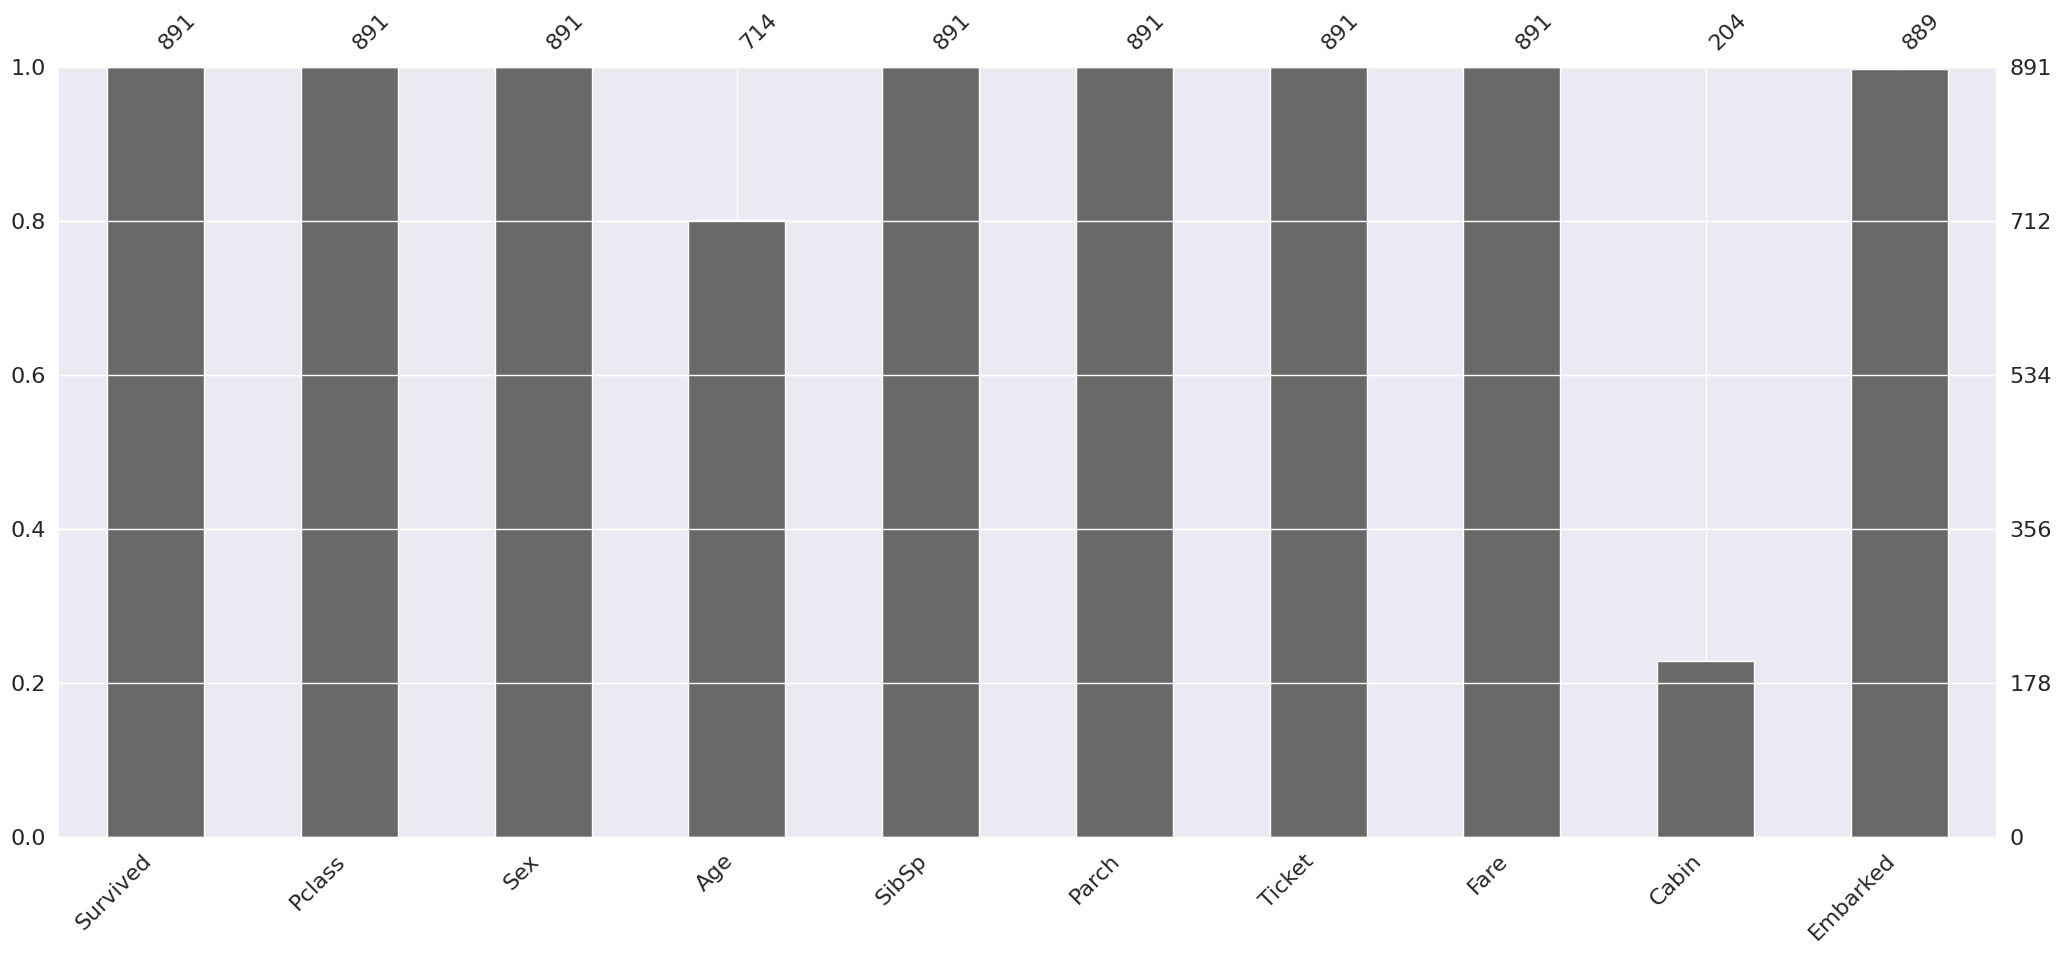

In [3]:
# Step 2: Handling Missing values
# Activity 1: Visualizing missing data
msno.bar(df)

# Activity 2: Detecting missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / len(df)) * 100
print(pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage}))

# Drop missing data
df = df.drop(columns=['Cabin'])

# Imputing missing values
# Fill missing values in the 'Age' column with the mean age
df['Age'] = df['Age'].fillna(df['Age'].mean())
# Fill missing values in the 'Fare' column with the median
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
# Fill missing values in the 'Embarked' column with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

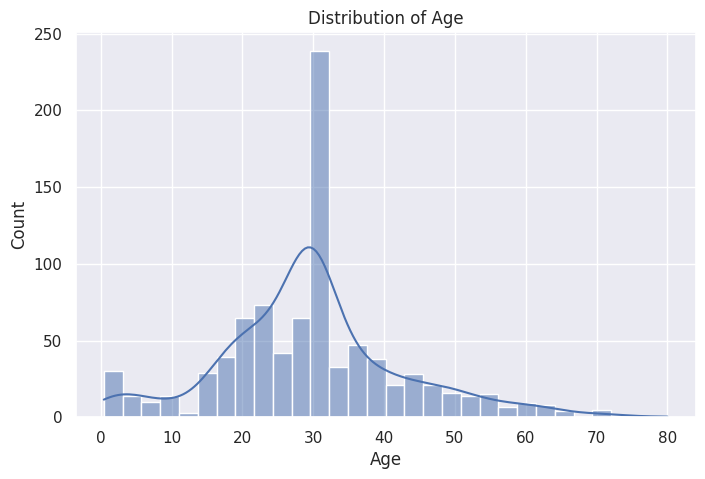

In [4]:
# Step 3: Univariate Analysis
# Univariate analysis for Numerical columns
# 1. Histogram for Age
plt.figure(figsize=(8, 5)) # Set the width and height respectively (in inches)
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

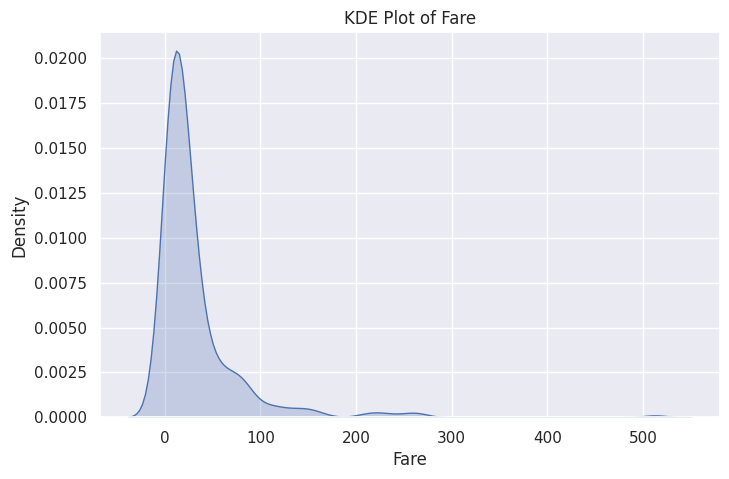

In [5]:
# 2. KDE Plot for Fare (Detecting Skewness)
plt.figure(figsize=(8, 5))
sns.kdeplot(df['Fare'], fill=True)
plt.title('KDE Plot of Fare')
plt.xlabel('Fare')
plt.show()

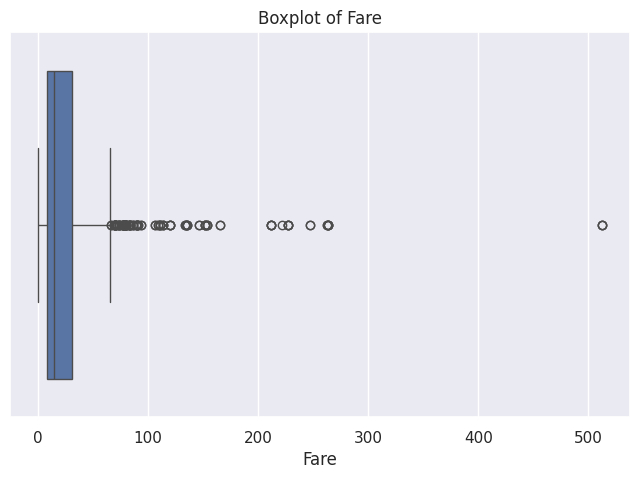

In [6]:
# 3. Boxplot for Fare (Detecting outliers)
plt.figure(figsize=(8, 5))
sns.boxplot(x = df['Fare'])
plt.title('Boxplot of Fare')
plt.show()

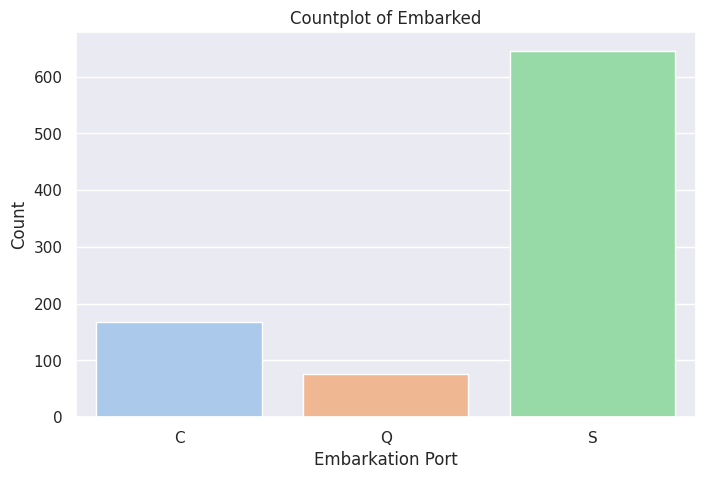

In [7]:
# Univariate analysis for categorical columns
# 1. Countplot (Count the frequency of each category in each column)
plt.figure(figsize = (8, 5))
sns.countplot(x='Embarked', data=df, hue='Embarked', palette='pastel', legend=False)
plt.title('Countplot of Embarked')
plt.xlabel('Embarkation Port')
plt.ylabel('Count')
plt.show()

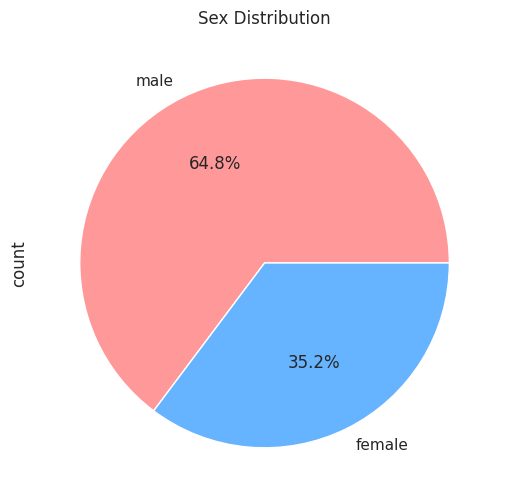

In [8]:
# 2. Pie chart (Useful for displaying proportions)
df['Sex'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6, 6 ), colors=['#ff9999', '#66b3ff'])
plt.title('Sex Distribution')
plt.show()

In [9]:
# Summary statistics for categorical variables
# Helps detect any rare categories
print(df['Pclass'].value_counts())

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


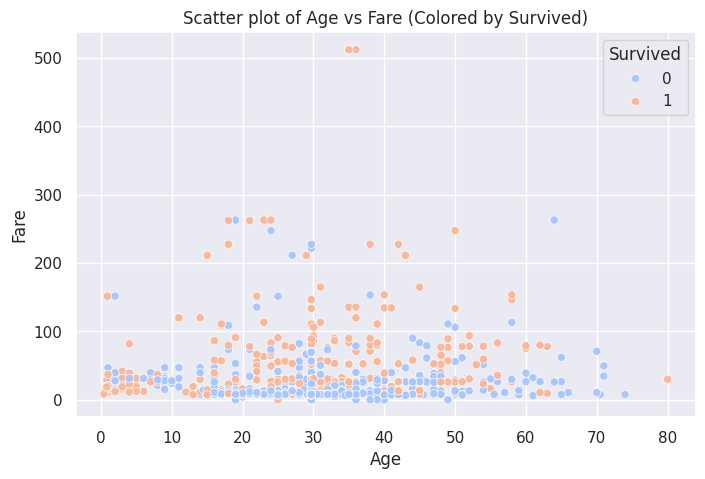

In [10]:
# Bivariate Analysis
# Numerical vs Numerical Analysis
# 1. Scatter plot (Age vs Fare)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Fare', data=df, hue='Survived', palette='coolwarm')
plt.title('Scatter plot of Age vs Fare (Colored by Survived)')
plt.show()

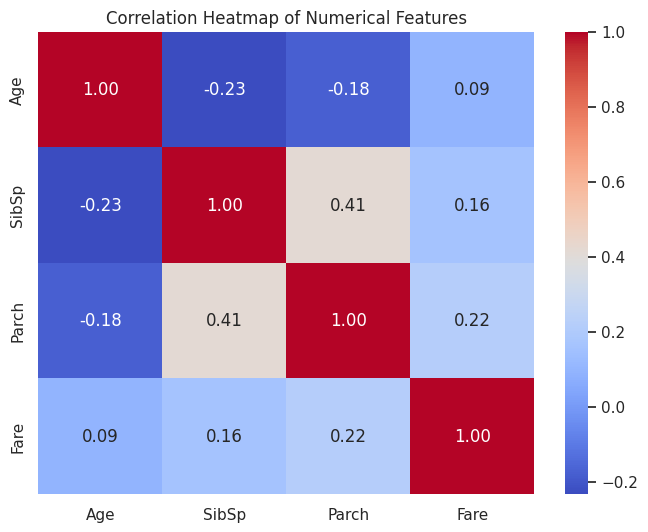

In [11]:
# 2. Correlation heatmap 
# Numerical columns only
plt.figure(figsize=(8, 6))
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns # Select only numerical columns
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

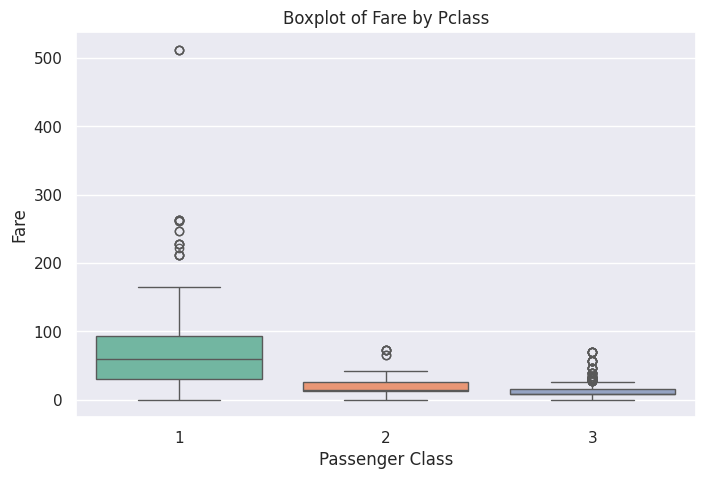

In [12]:
# Numerical vs Categorical Analysis
# 1. Boxplot (Fare groupedby Pclass)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Fare', hue='Pclass', data=df, palette='Set2', legend=False)
plt.title('Boxplot of Fare by Pclass')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

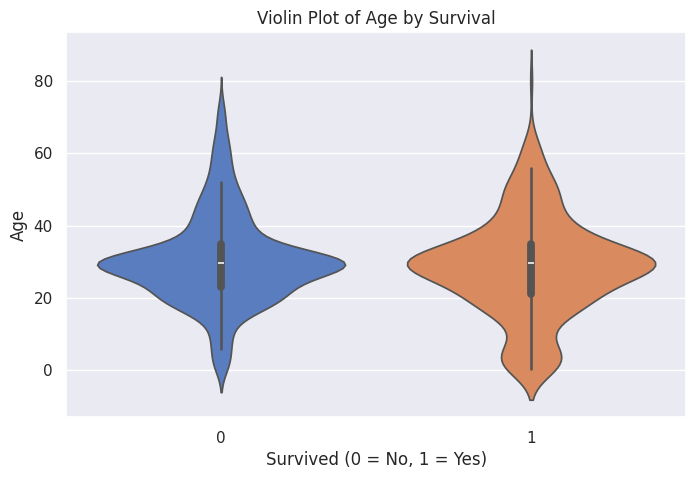

In [13]:
# 2. Violin Plot
# Excellent if you want to see both distribution and summary statistics
plt.figure(figsize=(8, 5))
sns.violinplot(x='Survived', y='Age', data=df, hue='Survived', palette='muted', legend=False)
plt.title('Violin Plot of Age by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

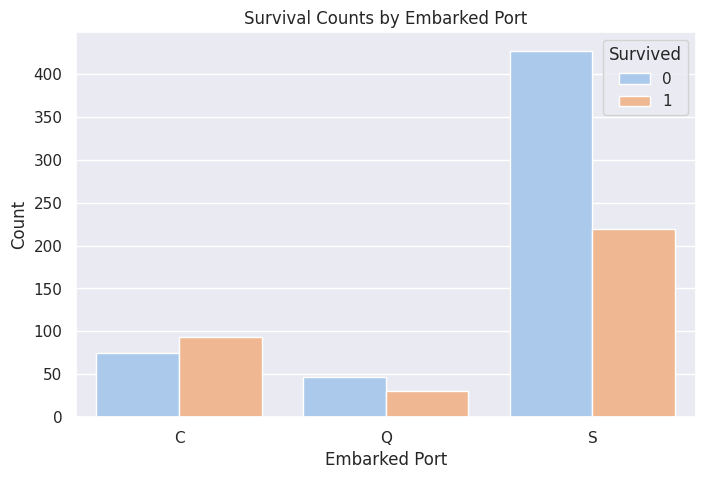

In [14]:
# Categorical vs Categorical Analysis
# Grouped bar plot of Survived vs Embarked
plt.figure(figsize=(8, 5))
sns.countplot(x='Embarked', hue='Survived', data=df, palette='pastel')
plt.title('Survival Counts by Embarked Port')
plt.xlabel('Embarked Port')
plt.ylabel('Count')
plt.show()

<Figure size 1000x1000 with 0 Axes>

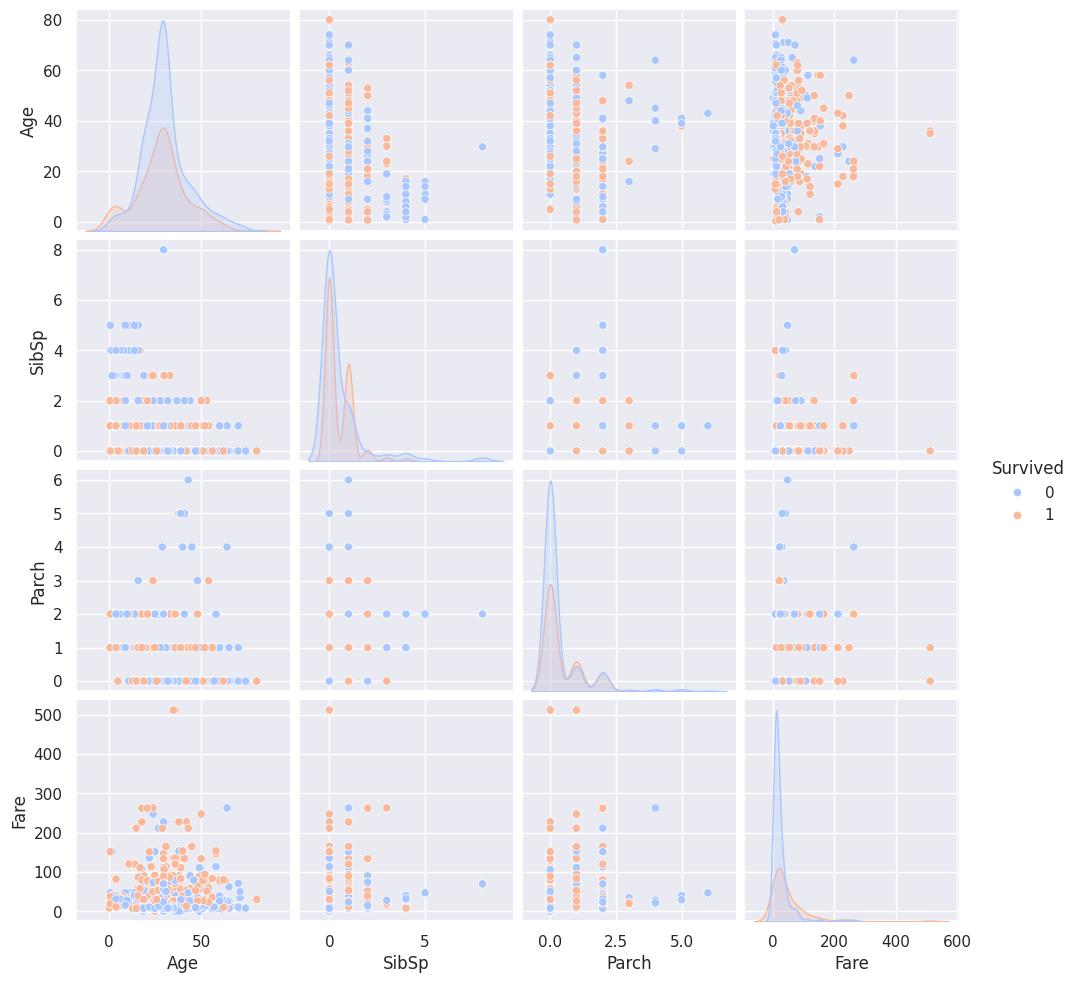

In [15]:
# Step 4: Multivariate Analysis
# Pair plot for numerical columns
plt.figure(figsize=(10, 10))
sns.pairplot(df, hue='Survived', diag_kind='kde', palette='coolwarm')
plt.show()

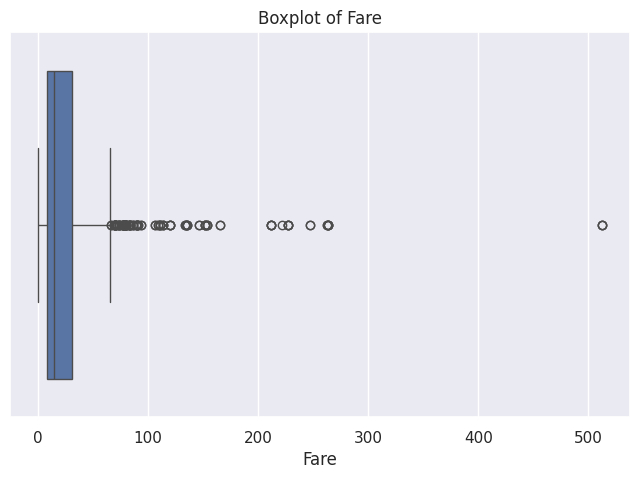

In [16]:
# Step 5: Outlier Detection and Handling
# Detecting outliers using Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Fare')
plt.title('Boxplot of Fare')
plt.show()

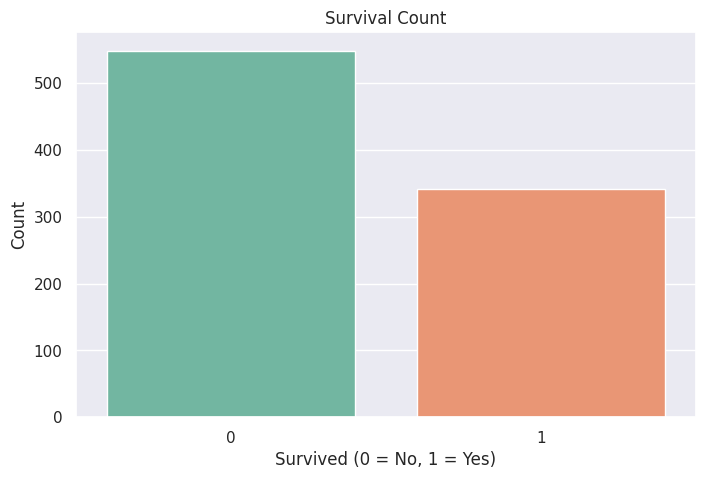

In [17]:
# Step 6: Target Variable Exploration
# Distribution of the Target Variable (Survived)
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', data=df, palette='Set2', hue='Survived', legend=False)
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()